In [2]:
! pip install nltk

Defaulting to user installation because normal site-packages is not writeable
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Using cached tqdm-4.68.3-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- --------

In [3]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

In [4]:
reviews = pd.read_csv("D:\\E-Commerce-Project\\cleaned_data\\reviews_cleaned.csv")

In [5]:
reviews.head(5)

,review_id,user_id,product_id,purchase_id,rating,title,review_text,review_date
0,e4ad6f1e-6449-4793-a131-17192b03e509,f6cadab8-2be9-4480-a278-71846245a809,99aee34b-3b16-4337-8132-f183349dfd69,UNKNOWN,4,A reliable purchase,This Staples Organization Set does exactly wha...,2022-01-13 00:00:00.000000000
1,0c5734c1-dacb-4028-a50a-507ca9c92aeb,d89694d2-292d-42d4-b090-947c1e292c98,38685bcb-3aef-4d81-abeb-101f9beee4fd,UNKNOWN,5,This Studio: A Comprehensive Guide is a game c...,I did not expect to love this as much as I do....,2022-01-15 00:00:00.000000000
2,d978ff74-a828-4f62-b550-f70664aca6aa,4f92de48-e30b-49e8-9584-8868945497d0,aba49dc2-3182-4614-a4ad-e2b537d50b04,UNKNOWN,4,Very satisfied with this Cuisinart Non-Stick K...,This Cuisinart Non-Stick Kitchenware has held ...,2022-01-26 00:00:00.000000000
3,50332ba8-4577-439d-8111-ef0b5960acd5,845e33f0-1aab-4df5-9a49-0a50fd5a4298,d30b76ee-5a18-4e36-bbb7-84723460be23,UNKNOWN,3,Not bad but not great either,This Fitness for Professionals gets the job do...,2022-02-02 00:00:00.000000000
4,8bdb7c01-41cf-44cb-99c9-8862c5d833b0,0da6cc24-2cd4-42dc-88e8-137951cd5ef5,61113e39-9a12-48a9-840b-dd7368dca11c,UNKNOWN,3,Function over form,This MSR Performance Cycling works fine but th...,2022-02-08 00:00:00.000000000


In [6]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to C:\Users\Nikhil
[nltk_data]     Dongare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Nikhil
[nltk_data]     Dongare\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = word_tokenize(text)

    words = [w for w in words if w not in stop_words]

    return " ".join(words)
reviews["clean_review"] = reviews["review_text"].apply(clean_text)

In [10]:
def sentiment(rating):

    if rating >=4:
        return "Positive"

    elif rating==3:
        return "Neutral"

    else:
        return "Negative"

reviews["Sentiment"] = reviews["rating"].apply(sentiment)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(reviews["clean_review"])

y = reviews["Sentiment"]

In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [14]:
prediction = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

print("Accuracy :",accuracy_score(y_test,prediction))

Accuracy : 1.0


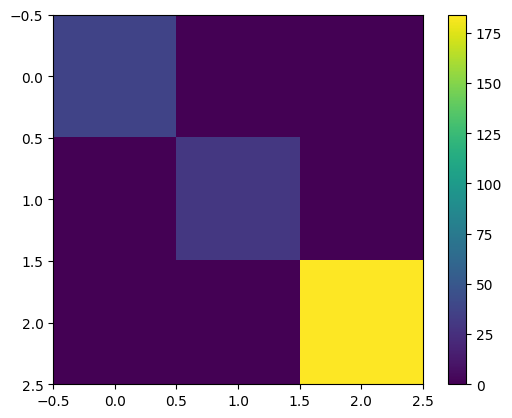

In [16]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,prediction)

plt.imshow(cm)

plt.colorbar()

plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        37
     Neutral       1.00      1.00      1.00        30
    Positive       1.00      1.00      1.00       184

    accuracy                           1.00       251
   macro avg       1.00      1.00      1.00       251
weighted avg       1.00      1.00      1.00       251



In [18]:
review = ["The product quality is amazing and delivery was fast"]

review = [clean_text(i) for i in review]

review = tfidf.transform(review)

print(model.predict(review))

['Positive']


In [19]:
! pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


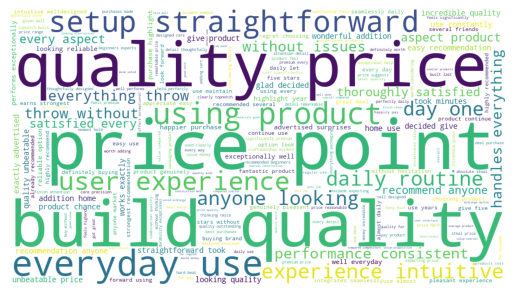

In [20]:
from wordcloud import WordCloud

text = " ".join(reviews["clean_review"])

wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
)

wc.generate(text)

plt.imshow(wc)

plt.axis("off")

plt.show()

In [21]:
import joblib

joblib.dump(model,"sentiment_model.pkl")

joblib.dump(tfidf,"tfidf.pkl")

['tfidf.pkl']